In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 1. Load Dataset

In [7]:
# Load cleaned dataset
df = pd.read_csv('../data/processed/cleaned_dataset.csv')

# Extract student ID
df['student_id'] = df['source_file'].str.extract(r'-(\d+)\.csv$')[0]

print(f"Dataset loaded: {df.shape[0]} records, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset loaded: 955 records, 12 columns

Columns: ['source_file', 'Image URL', 'Description', 'Country', 'Country_Standardized', 'Time of Day', 'Time_of_Day_Standardized', 'preference', 'student_id', 'Activity_Type', 'Weather_Type', 'Mood_Category']


,source_file,Image URL,Description,Country,Country_Standardized,Time of Day,Time_of_Day_Standardized,preference,student_id,Activity_Type,Weather_Type,Mood_Category
0,2936035-1161937.csv,https://commons.wikimedia.org/wiki/File:Dom_of...,a clear image of the dome of the rock in jerus...,palestine,Palestine,afternoon,Afternoon,1,1161937,Nature,Sunny,Relaxing
1,2936035-1161937.csv,https://upload.wikimedia.org/wikipedia/commons...,a clear image of the ibrahimi mosque (cave of ...,palestine,Palestine,morning,Morning,1,1161937,Nature,Sunny,Relaxing
2,2936035-1161937.csv,https://upload.wikimedia.org/wikipedia/commons...,a clear image of the ancient ruins in sebastia...,palestine,Palestine,afternoon,Afternoon,1,1161937,History,Sunny,Relaxing
3,2936035-1161937.csv,https://upload.wikimedia.org/wikipedia/commons...,a clear image of mar saba monastery in bethleh...,palestine,Palestine,afternoon,Afternoon,1,1161937,Nature,Sunny,Relaxing
4,2936035-1161937.csv,https://upload.wikimedia.org/wikipedia/commons...,a clear aerial view of tell es-sultan in jeric...,palestine,Palestine,morning,Morning,1,1161937,Nature,Sunny,Relaxing


## 2. Dataset Overview

In [8]:
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)

# Basic statistics
n_students = df['student_id'].nunique()
n_records = len(df)
n_unique_images = df['Image URL'].nunique()
n_unique_countries = df['Country_Standardized'].nunique()

print(f"\n📊 Dataset Size:")
print(f"  • Total students: {n_students}")
print(f"  • Total records: {n_records}")
print(f"  • Unique places (images): {n_unique_images}")
print(f"  • Unique countries: {n_unique_countries}")
print(f"  • Average places per student: {n_records / n_students:.2f}")

print(f"\n📂 Data Types:")
print(df.dtypes)

print(f"\n🔍 Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])
if missing.sum() == 0:
    print("  ✓ No missing values!")

DATASET OVERVIEW

📊 Dataset Size:
  • Total students: 88
  • Total records: 955
  • Unique places (images): 955
  • Unique countries: 89
  • Average places per student: 10.85

📂 Data Types:
source_file                 object
Image URL                   object
Description                 object
Country                     object
Country_Standardized        object
Time of Day                 object
Time_of_Day_Standardized    object
preference                   int64
student_id                  object
Activity_Type               object
Weather_Type                object
Mood_Category               object
dtype: object

🔍 Missing Values:
            Missing Count  Percentage
Country                 1    0.104712
student_id             60    6.282723


## 3. Places per Student Distribution

PLACES PER STUDENT DISTRIBUTION

📈 Statistics:
count    88.000000
mean     10.170455
std       2.012727
min       6.000000
25%      10.000000
50%      10.000000
75%      10.000000
max      20.000000
dtype: float64

📊 Distribution:
6      1
8      2
9     13
10    67
11     1
16     1
19     1
20     2
Name: count, dtype: int64


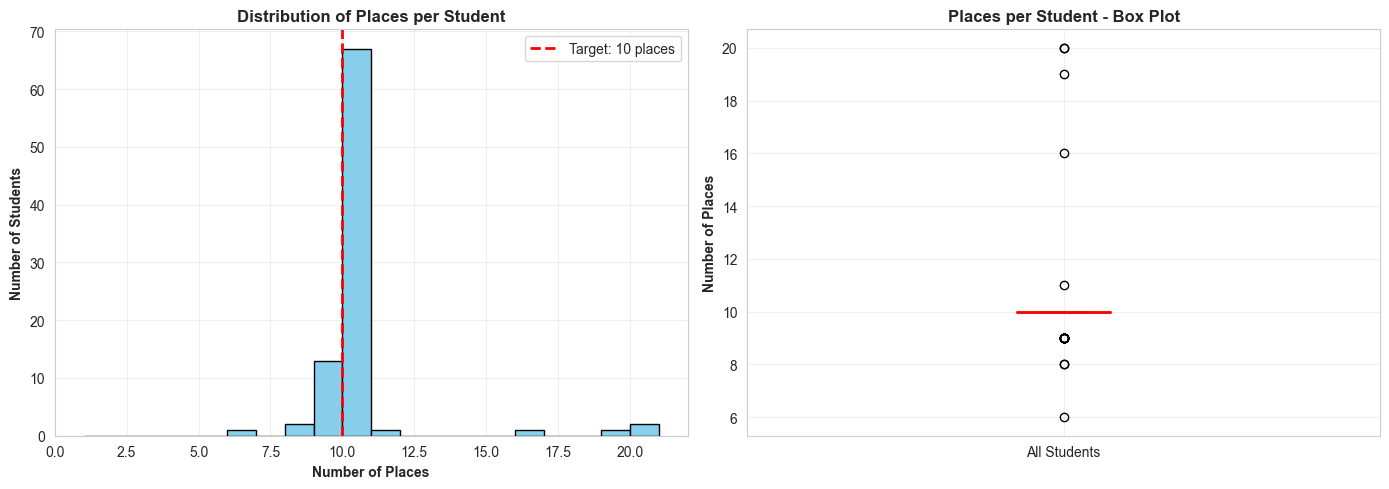


✓ Saved: results/figures/eda_visuals/places_per_student.png


In [9]:
print("=" * 80)
print("PLACES PER STUDENT DISTRIBUTION")
print("=" * 80)

# Count places per student
places_per_student = df.groupby('student_id').size()

print(f"\n📈 Statistics:")
print(places_per_student.describe())

print(f"\n📊 Distribution:")
print(places_per_student.value_counts().sort_index())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
places_per_student.hist(bins=range(1, places_per_student.max() + 2), 
                        edgecolor='black', color='skyblue', ax=ax)
ax.axvline(x=10, color='red', linestyle='--', linewidth=2, label='Target: 10 places')
ax.set_xlabel('Number of Places', fontweight='bold')
ax.set_ylabel('Number of Students', fontweight='bold')
ax.set_title('Distribution of Places per Student', fontweight='bold', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)

# Box plot
ax = axes[1]
ax.boxplot([places_per_student], vert=True, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='black'),
           medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('Number of Places', fontweight='bold')
ax.set_title('Places per Student - Box Plot', fontweight='bold', fontsize=12)
ax.set_xticklabels(['All Students'])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/eda_visuals/places_per_student.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: results/figures/eda_visuals/places_per_student.png")

## 4. Students per Place Distribution

STUDENTS PER PLACE DISTRIBUTION

📈 Statistics:
count    955.000000
mean       0.937173
std        0.242779
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: student_id, dtype: float64

📊 Distribution:
student_id
0     60
1    895
Name: count, dtype: int64

🏆 Top 10 Most Popular Places:
  1. 1 students - Palestine - History
  2. 1 students - Russia - Urban
  3. 1 students - Canada - Nature
  4. 1 students - Iceland - Nature
  5. 1 students - Colombia - Nature
  6. 1 students - Indonesia - Nature
  7. 1 students - Canada - Nature
  8. 1 students - Greece - Nature
  9. 1 students - Italy - History
  10. 1 students - USA - History


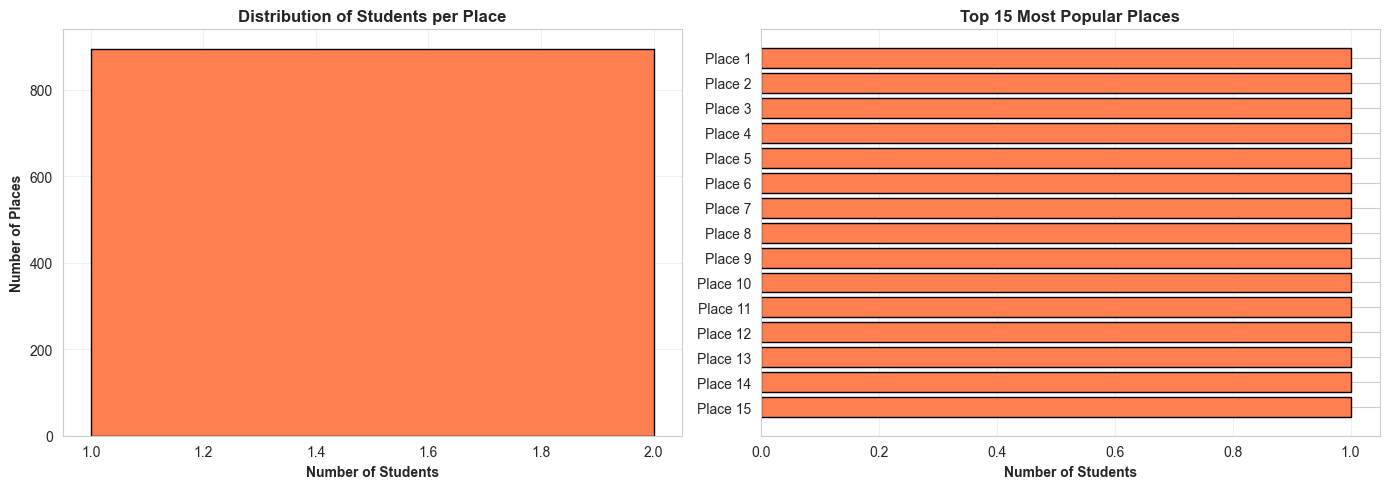


✓ Saved: results/figures/eda_visuals/students_per_place.png

❄️ Cold-Start Analysis:
  • Places visited by only 1 student: 895 (93.7%)
  • Places visited by 2+ students: 0 (0.0%)


In [10]:
print("=" * 80)
print("STUDENTS PER PLACE DISTRIBUTION")
print("=" * 80)

# Count students per unique place (image URL)
students_per_place = df.groupby('Image URL')['student_id'].nunique()

print(f"\n📈 Statistics:")
print(students_per_place.describe())

print(f"\n📊 Distribution:")
print(students_per_place.value_counts().sort_index().head(20))

# Find most popular places
print(f"\n🏆 Top 10 Most Popular Places:")
top_places = students_per_place.sort_values(ascending=False).head(10)
for i, (url, count) in enumerate(top_places.items(), 1):
    place_info = df[df['Image URL'] == url].iloc[0]
    print(f"  {i}. {count} students - {place_info['Country_Standardized']} - {place_info['Activity_Type']}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
students_per_place.hist(bins=range(1, min(students_per_place.max() + 2, 21)), 
                        edgecolor='black', color='coral', ax=ax)
ax.set_xlabel('Number of Students', fontweight='bold')
ax.set_ylabel('Number of Places', fontweight='bold')
ax.set_title('Distribution of Students per Place', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)

# Top 15 most popular places
ax = axes[1]
top_15 = students_per_place.sort_values(ascending=False).head(15)
ax.barh(range(len(top_15)), top_15.values, color='coral', edgecolor='black')
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels([f'Place {i+1}' for i in range(len(top_15))])
ax.set_xlabel('Number of Students', fontweight='bold')
ax.set_title('Top 15 Most Popular Places', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3, axis='x')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../results/figures/eda_visuals/students_per_place.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: results/figures/eda_visuals/students_per_place.png")

# Cold-start analysis
unique_places = (students_per_place == 1).sum()
print(f"\n❄️ Cold-Start Analysis:")
print(f"  • Places visited by only 1 student: {unique_places} ({unique_places/len(students_per_place)*100:.1f}%)")
print(f"  • Places visited by 2+ students: {(students_per_place >= 2).sum()} ({(students_per_place >= 2).sum()/len(students_per_place)*100:.1f}%)")

## 5. Metadata Distributions

In [11]:
print("=" * 80)
print("METADATA DISTRIBUTIONS")
print("=" * 80)

# Weather distribution
print(f"\n☀️ Weather Types ({df['Weather_Type'].nunique()} categories):")
weather_counts = df['Weather_Type'].value_counts()
for weather, count in weather_counts.items():
    print(f"  • {weather}: {count} ({count/len(df)*100:.1f}%)")

# Activity distribution
print(f"\n🎯 Activity Types ({df['Activity_Type'].nunique()} categories):")
activity_counts = df['Activity_Type'].value_counts()
for activity, count in activity_counts.items():
    print(f"  • {activity}: {count} ({count/len(df)*100:.1f}%)")

# Mood distribution
print(f"\n😊 Mood Categories ({df['Mood_Category'].nunique()} categories):")
mood_counts = df['Mood_Category'].value_counts()
for mood, count in mood_counts.items():
    print(f"  • {mood}: {count} ({count/len(df)*100:.1f}%)")

# Country distribution
print(f"\n🌍 Top 15 Countries:")
country_counts = df['Country_Standardized'].value_counts().head(15)
for country, count in country_counts.items():
    print(f"  • {country}: {count} ({count/len(df)*100:.1f}%)")

METADATA DISTRIBUTIONS

☀️ Weather Types (5 categories):
  • Sunny: 784 (82.1%)
  • Snowy: 126 (13.2%)
  • Rainy: 23 (2.4%)
  • Cloudy: 13 (1.4%)
  • Windy: 9 (0.9%)

🎯 Activity Types (4 categories):
  • Nature: 619 (64.8%)
  • History: 118 (12.4%)
  • Leisure/Other: 114 (11.9%)
  • Urban: 104 (10.9%)

😊 Mood Categories (5 categories):
  • Relaxing: 776 (81.3%)
  • Inpsiring: 65 (6.8%)
  • Romantic: 58 (6.1%)
  • Exciting: 52 (5.4%)
  • Melancholic: 4 (0.4%)

🌍 Top 15 Countries:
  • Italy: 65 (6.8%)
  • Japan: 62 (6.5%)
  • USA: 57 (6.0%)
  • France: 50 (5.2%)
  • Switzerland: 49 (5.1%)
  • Spain: 49 (5.1%)
  • Palestine: 44 (4.6%)
  • Maldives: 35 (3.7%)
  • Greece: 35 (3.7%)
  • Turkey: 34 (3.6%)
  • UK: 32 (3.4%)
  • Egypt: 29 (3.0%)
  • Saudi Arabia: 26 (2.7%)
  • UAE: 23 (2.4%)
  • China: 23 (2.4%)


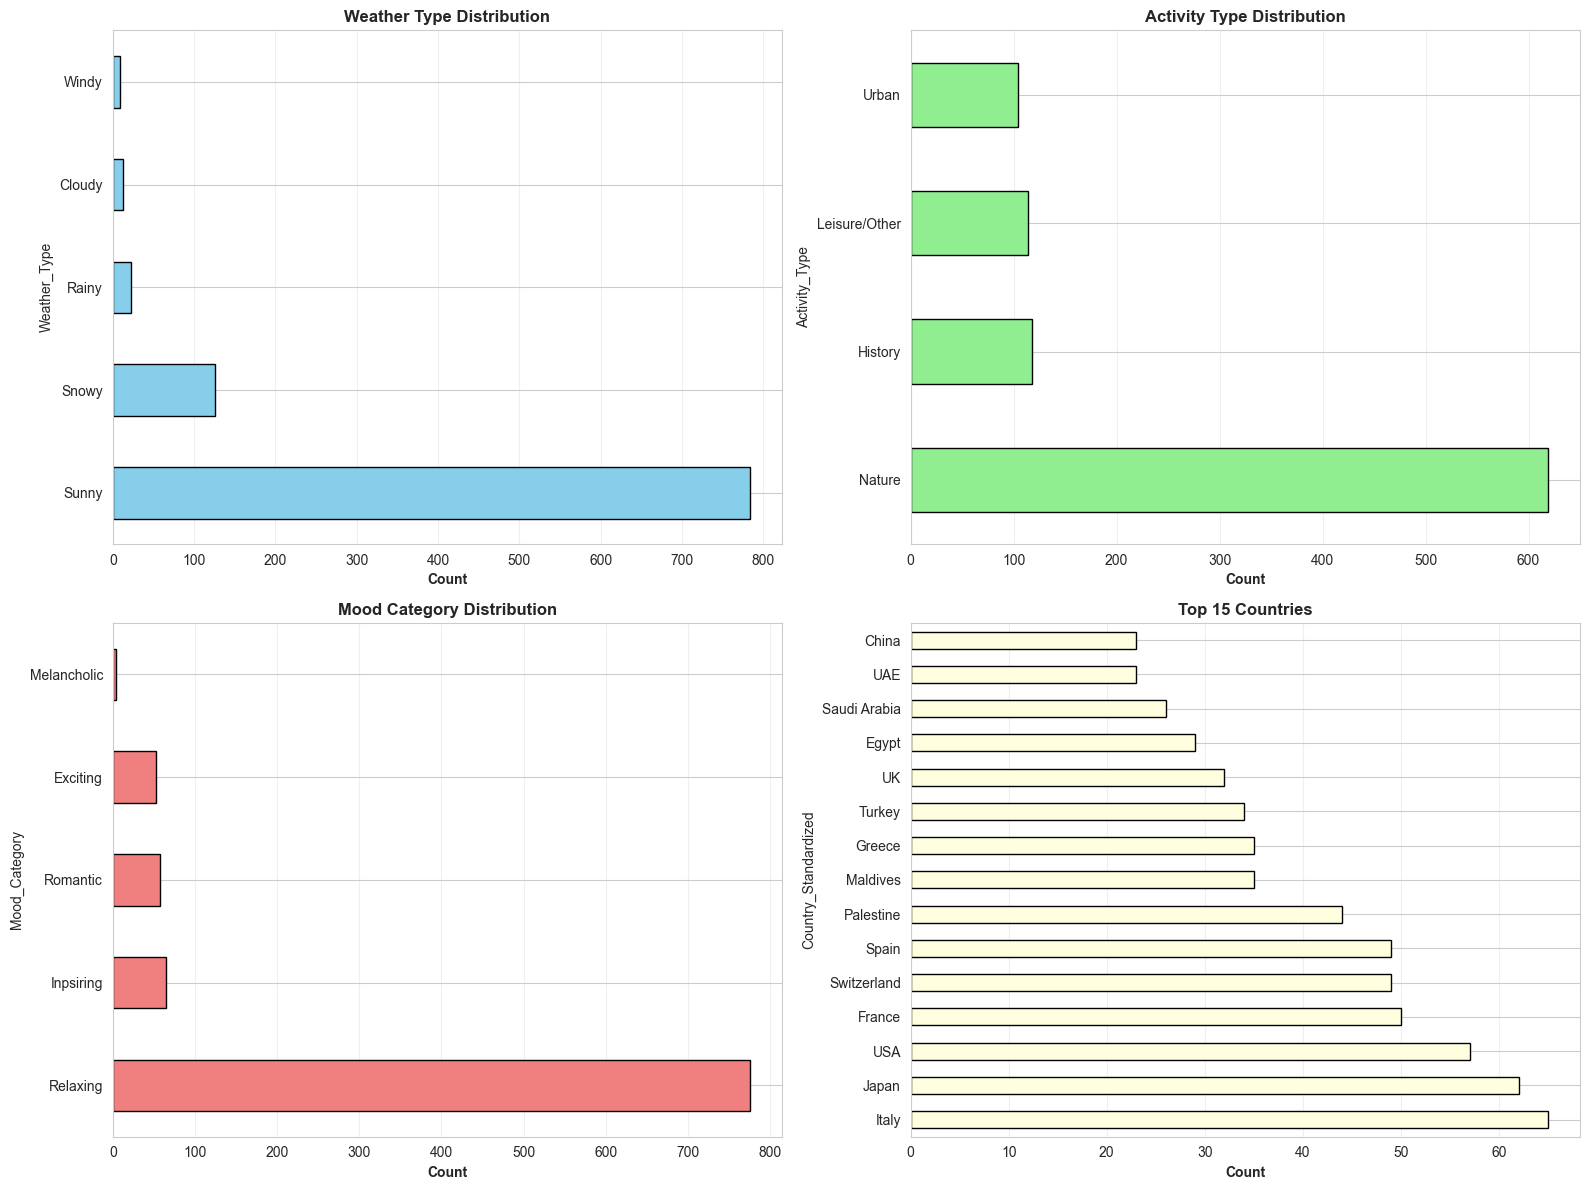

✓ Saved: results/figures/eda_visuals/metadata_distributions.png


In [12]:
# Visualize metadata distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Weather distribution
ax = axes[0, 0]
weather_counts.plot(kind='barh', ax=ax, color='skyblue', edgecolor='black')
ax.set_xlabel('Count', fontweight='bold')
ax.set_title('Weather Type Distribution', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3, axis='x')

# Activity distribution
ax = axes[0, 1]
activity_counts.plot(kind='barh', ax=ax, color='lightgreen', edgecolor='black')
ax.set_xlabel('Count', fontweight='bold')
ax.set_title('Activity Type Distribution', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3, axis='x')

# Mood distribution
ax = axes[1, 0]
mood_counts.plot(kind='barh', ax=ax, color='lightcoral', edgecolor='black')
ax.set_xlabel('Count', fontweight='bold')
ax.set_title('Mood Category Distribution', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3, axis='x')

# Top 15 countries
ax = axes[1, 1]
country_counts.plot(kind='barh', ax=ax, color='lightyellow', edgecolor='black')
ax.set_xlabel('Count', fontweight='bold')
ax.set_title('Top 15 Countries', fontweight='bold', fontsize=12)
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../results/figures/eda_visuals/metadata_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: results/figures/eda_visuals/metadata_distributions.png")

## 6. Class Imbalance Analysis

CLASS IMBALANCE ANALYSIS

📊 Imbalance Metrics:

Weather Types:
  • Imbalance Ratio: 87.11
  • Gini Coefficient: 0.697
  • Most common: Sunny (784 samples)
  • Least common: Windy (9 samples)

Activity Types:
  • Imbalance Ratio: 5.95
  • Gini Coefficient: 0.405
  • Most common: Nature (619 samples)
  • Least common: Urban (104 samples)

Mood Categories:
  • Imbalance Ratio: 194.00
  • Gini Coefficient: 0.652
  • Most common: Relaxing (776 samples)
  • Least common: Melancholic (4 samples)


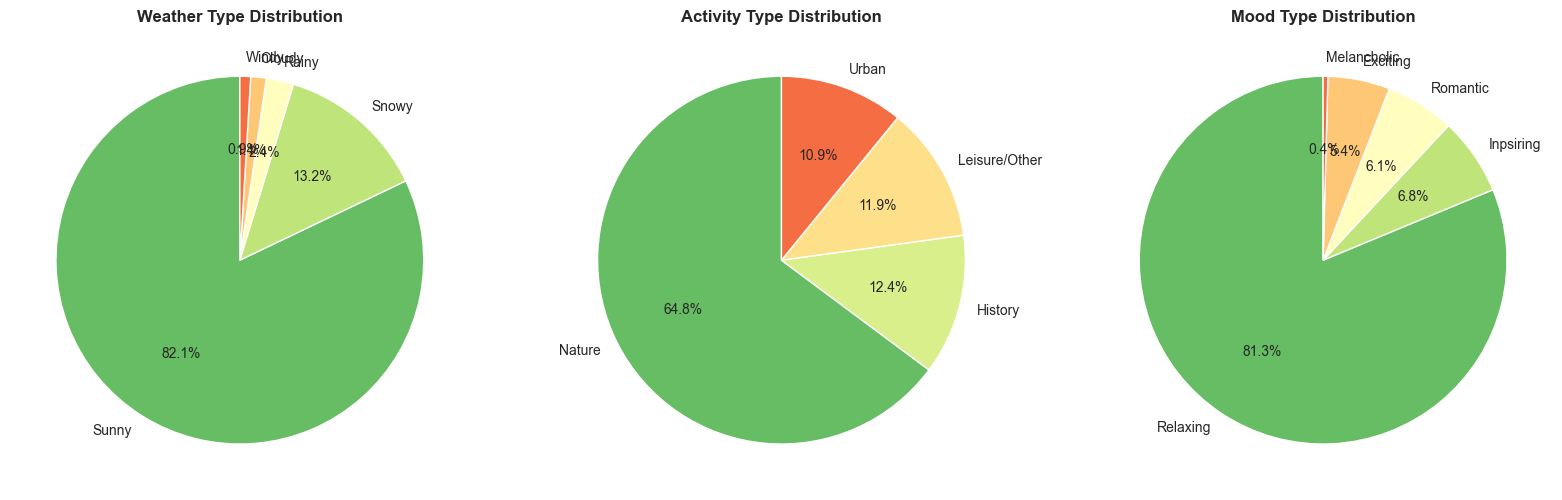


✓ Saved: results/figures/eda_visuals/class_imbalance.png


In [13]:
print("=" * 80)
print("CLASS IMBALANCE ANALYSIS")
print("=" * 80)

# Calculate imbalance ratios
def calculate_imbalance_ratio(counts):
    """Calculate imbalance ratio (max/min)"""
    return counts.max() / counts.min()

def calculate_gini(counts):
    """Calculate Gini coefficient for imbalance"""
    n = len(counts)
    sorted_counts = np.sort(counts.values)
    cumsum = np.cumsum(sorted_counts)
    return (2 * np.sum((np.arange(1, n+1)) * sorted_counts)) / (n * cumsum[-1]) - (n + 1) / n

print(f"\n📊 Imbalance Metrics:")
print(f"\nWeather Types:")
print(f"  • Imbalance Ratio: {calculate_imbalance_ratio(weather_counts):.2f}")
print(f"  • Gini Coefficient: {calculate_gini(weather_counts):.3f}")
print(f"  • Most common: {weather_counts.index[0]} ({weather_counts.iloc[0]} samples)")
print(f"  • Least common: {weather_counts.index[-1]} ({weather_counts.iloc[-1]} samples)")

print(f"\nActivity Types:")
print(f"  • Imbalance Ratio: {calculate_imbalance_ratio(activity_counts):.2f}")
print(f"  • Gini Coefficient: {calculate_gini(activity_counts):.3f}")
print(f"  • Most common: {activity_counts.index[0]} ({activity_counts.iloc[0]} samples)")
print(f"  • Least common: {activity_counts.index[-1]} ({activity_counts.iloc[-1]} samples)")

print(f"\nMood Categories:")
print(f"  • Imbalance Ratio: {calculate_imbalance_ratio(mood_counts):.2f}")
print(f"  • Gini Coefficient: {calculate_gini(mood_counts):.3f}")
print(f"  • Most common: {mood_counts.index[0]} ({mood_counts.iloc[0]} samples)")
print(f"  • Least common: {mood_counts.index[-1]} ({mood_counts.iloc[-1]} samples)")

# Visualize imbalance
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (title, counts) in zip(axes, [
    ('Weather', weather_counts),
    ('Activity', activity_counts),
    ('Mood', mood_counts)
]):
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(counts)))
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
    ax.set_title(f'{title} Type Distribution', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../results/figures/eda_visuals/class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: results/figures/eda_visuals/class_imbalance.png")

## 7. Load Training Pairs and Analyze Balance

In [14]:
# Check if training pairs exist
train_pairs_path = Path('../data/splits/train_pairs.csv')

if train_pairs_path.exists():
    print("=" * 80)
    print("TRAINING PAIRS CLASS BALANCE")
    print("=" * 80)
    
    pairs_df = pd.read_csv(train_pairs_path)
    
    print(f"\n📊 Training Pairs Overview:")
    print(f"  • Total pairs: {len(pairs_df)}")
    
    if 'label' in pairs_df.columns:
        label_counts = pairs_df['label'].value_counts()
        print(f"  • Positive pairs: {label_counts.get(1, 0)} ({label_counts.get(1, 0)/len(pairs_df)*100:.1f}%)")
        print(f"  • Negative pairs: {label_counts.get(0, 0)} ({label_counts.get(0, 0)/len(pairs_df)*100:.1f}%)")
        print(f"  • Positive/Negative ratio: 1:{label_counts.get(0, 0)/label_counts.get(1, 1):.2f}")
        
        # Visualize
        fig, ax = plt.subplots(figsize=(8, 6))
        labels = ['Negative (0)', 'Positive (1)']
        colors = ['#e74c3c', '#2ecc71']
        ax.bar(labels, [label_counts.get(0, 0), label_counts.get(1, 0)], 
               color=colors, edgecolor='black', linewidth=2)
        ax.set_ylabel('Number of Pairs', fontweight='bold')
        ax.set_title('Training Pairs Label Distribution', fontweight='bold', fontsize=12)
        ax.grid(alpha=0.3, axis='y')
        
        for i, (label, count) in enumerate([(0, label_counts.get(0, 0)), (1, label_counts.get(1, 0))]):
            ax.text(i, count + 10, f'{count}\n({count/len(pairs_df)*100:.1f}%)', 
                   ha='center', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('../results/figures/eda_visuals/training_pairs_balance.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\n✓ Saved: results/figures/eda_visuals/training_pairs_balance.png")
else:
    print("\n⚠️ Training pairs not yet generated (Task 1.4)")


⚠️ Training pairs not yet generated (Task 1.4)


## 8. Summary Statistics

In [15]:
print("=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

summary = {
    'Dataset Overview': {
        'Total Students': n_students,
        'Total Records': n_records,
        'Unique Places': n_unique_images,
        'Unique Countries': n_unique_countries,
        'Avg Places per Student': f"{n_records / n_students:.2f}"
    },
    'Metadata Categories': {
        'Weather Types': df['Weather_Type'].nunique(),
        'Activity Types': df['Activity_Type'].nunique(),
        'Mood Categories': df['Mood_Category'].nunique()
    },
    'Class Imbalance': {
        'Weather Imbalance Ratio': f"{calculate_imbalance_ratio(weather_counts):.2f}",
        'Activity Imbalance Ratio': f"{calculate_imbalance_ratio(activity_counts):.2f}",
        'Mood Imbalance Ratio': f"{calculate_imbalance_ratio(mood_counts):.2f}"
    },
    'Place Popularity': {
        'Unique Places (1 student only)': f"{unique_places} ({unique_places/len(students_per_place)*100:.1f}%)",
        'Shared Places (2+ students)': f"{(students_per_place >= 2).sum()} ({(students_per_place >= 2).sum()/len(students_per_place)*100:.1f}%)"
    }
}

for category, stats in summary.items():
    print(f"\n{category}:")
    for key, value in stats.items():
        print(f"  • {key}: {value}")

# Save summary to JSON
output_dir = Path('../results/metrics')
output_dir.mkdir(parents=True, exist_ok=True)

with open(output_dir / 'eda_statistics_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\n✓ Saved: results/metrics/eda_statistics_summary.json")

SUMMARY STATISTICS

Dataset Overview:
  • Total Students: 88
  • Total Records: 955
  • Unique Places: 955
  • Unique Countries: 89
  • Avg Places per Student: 10.85

Metadata Categories:
  • Weather Types: 5
  • Activity Types: 4
  • Mood Categories: 5

Class Imbalance:
  • Weather Imbalance Ratio: 87.11
  • Activity Imbalance Ratio: 5.95
  • Mood Imbalance Ratio: 194.00

Place Popularity:
  • Unique Places (1 student only): 895 (93.7%)
  • Shared Places (2+ students): 0 (0.0%)

✓ Saved: results/metrics/eda_statistics_summary.json


## 9. Task Completion Summary

In [16]:
print("=" * 80)
print("TASK 1.5a COMPLETE: EDA BASIC STATISTICS")
print("=" * 80)

print("\n✓ Checklist Completed:")
print("  ✓ Dataset overview (students, places, unique places)")
print("  ✓ Places per student distribution")
print("  ✓ Students per place distribution")
print("  ✓ Metadata distributions (weather, activity, mood)")
print("  ✓ Class imbalance analysis")

print("\n✓ Deliverables:")
print("  ✓ notebooks/eda_statistics.ipynb")
print("  ✓ results/figures/eda_visuals/places_per_student.png")
print("  ✓ results/figures/eda_visuals/students_per_place.png")
print("  ✓ results/figures/eda_visuals/metadata_distributions.png")
print("  ✓ results/figures/eda_visuals/class_imbalance.png")
print("  ✓ results/metrics/eda_statistics_summary.json")

print("\n" + "=" * 80)

TASK 1.5a COMPLETE: EDA BASIC STATISTICS

✓ Checklist Completed:
  ✓ Dataset overview (students, places, unique places)
  ✓ Places per student distribution
  ✓ Students per place distribution
  ✓ Metadata distributions (weather, activity, mood)
  ✓ Class imbalance analysis

✓ Deliverables:
  ✓ notebooks/eda_statistics.ipynb
  ✓ results/figures/eda_visuals/places_per_student.png
  ✓ results/figures/eda_visuals/students_per_place.png
  ✓ results/figures/eda_visuals/metadata_distributions.png
  ✓ results/figures/eda_visuals/class_imbalance.png
  ✓ results/metrics/eda_statistics_summary.json

